In [1]:
import sys
sys.path.append('..')
import os

import awkward as ak
import numpy as np
import uproot as uproot
import matplotlib.pyplot as plt
import mplhep as hep
import vector as vec
import matplotlib
from tqdm import tqdm

from Timing.plotting import *

from numba import prange

plt.style.use(hep.style.CMS)
%matplotlib inline

In [2]:
from numba import njit
import awkward.numba

@njit
def flatten_numba(a):
    return [x[0] if len(x) else 0 for x in a]

def dist(refEta, refPhi, otherTsEta, otherTsPhi):
    return ((otherTsEta-refEta)**2 + (otherTsPhi-refPhi)**2)**0.5

@njit
def dist_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    out = []
    for i in range(len(otherTsEta)):
        distance = ((otherTsEta[i] - refEta) ** 2 + (otherTsPhi[i] - refPhi) ** 2) ** 0.5
        out.append(distance)
    return np.array(out)

@njit
def distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    out = []
    for i in range(len(otherTsEta)):
        deltaPhi = otherTsPhi[i] - refPhi
        deltaPhi = (deltaPhi + np.pi) % (2 * np.pi) - np.pi
        distance = ((otherTsEta[i] - refEta) ** 2 + deltaPhi ** 2) ** 0.5
        out.append(distance)
    return np.array(out)
   
def find_track_id(array, number):
    try:
        return np.where(array == number)[0][0]
    except:
        return -1

In [3]:
def load_branch_with_highest_cycle(file, branch_name):
    # Get all keys in the file
    all_keys = file.keys()
    # Filter keys that match the specified branch name
    matching_keys = [key for key in all_keys if key.startswith(branch_name)]
    if not matching_keys:
        raise ValueError(f"No branch with name '{branch_name}' found in the file.")
    # Find the key with the highest cycle
    highest_cycle_key = max(matching_keys, key=lambda key: int(key.split(";")[1]))
    # Load the branch with the highest cycle
    branch = file[highest_cycle_key]
    return branch

In [4]:
C = 29.9792458 #cm/ns

def distance(x1,y1,z1,x2,y2,z2):
    return ((x1-x2)**2+(y1-y2)**2+(z1-z2)**2)**0.5

# returns res that contains the parameters, the chi squared and 
# the counts and bins used to plot the data
def gauss_fit(data, init_parms, bins=300):
    hist, nbins = np.histogram(data, bins=bins)
    nbins = 0.5 * (bins[1:] + bins[:-1])
    errors = [np.sqrt(oh+1) for oh in hist]
    init_parameters = init_parms
    cost_func = cost.LeastSquares(nbins, hist, errors, model)
    min_obj = Minuit(cost_func, *init_parameters)
    res = min_obj.migrad()
    chi2 = min_obj.fval/(len(nbins[:-1])-3)
    return res, chi2, hist, nbins[:-1]

#same as above but plots also the data
def gauss_fit_and_plot(data, init_parms, label="data", colors=["midnightblue","dodgerblue"], bins=300):
    res, chi2, hists, newbins = gauss_fit(data, init_parms, bins=bins)
    y = model(newbins, *res.values)
    plt.plot(newbins, y, label=f'gauss fit\n   $\sigma$ = {res.values[2]:.3f} $\pm$ {res.errors[2]:.3f}\n   $x_0$ = {res.values[1]:.3f} $\pm$ {res.errors[1]:.3f} \n   $\chi^2_0$ = {chi2:.3f}', color=colors[0], linewidth=2)
    plt.hist(np.array(data), bins=bins, color=colors[1], alpha=0.7)
    plt.legend(fontsize=16)
    plt.grid()
    return res, chi2

# quick plot with list, np array or flattened awkward array
def myhist(X, bins=30, title='title', xlabel='time (ns)', ylabel='Counts / bin', color='dodgerblue', alpha=1, fill='stepfilled', range=None, label="data"):
    #plt.figure(dpi=100)
    if range==None:
        plt.hist(np.array(X), bins=bins, color=color, alpha=alpha, histtype=fill, label=label)
    else:
        plt.hist(np.array(X), bins=bins, color=color, alpha=alpha, histtype=fill, range=range, label=label)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid()  

In [15]:
tracksKeys = [
 'track_id',
 'track_hgcal_x',
 'track_hgcal_y',
 'track_hgcal_z',
 'track_hgcal_eta',
 'track_hgcal_phi',
 'track_hgcal_pt',
 'track_pt',
 'track_missing_outer_hits',
 'track_missing_inner_hits',
 'track_quality',
#  'track_charge',
#  'track_time',
#  'track_time_quality',
#  'track_time_err',
#  'track_beta',
 'track_time_mtd',
 'track_time_mtd_err',
#  'track_pos_mtd',
#  'track_pos_mtd/track_pos_mtd.theVector.theX',
#  'track_pos_mtd/track_pos_mtd.theVector.theY',
#  'track_pos_mtd/track_pos_mtd.theVector.theZ',
 'track_nhits',
 'track_isMuon',
 'track_isTrackerMuon'
]

simTsKeys = [
 'regressed_energy',
 'raw_energy',
 'trackIdx',
 # 'raw_em_energy',
 # 'raw_pt',
 # 'raw_em_pt',
 # 'barycenter_x',
 # 'barycenter_y',
 'barycenter_z',
 'barycenter_eta',
 'barycenter_phi',
 'trackTime',
 # 'EV1',
 # 'EV2',
 # 'EV3',
 # 'eVector0_x',
 # 'eVector0_y',
 # 'eVector0_z',
 # 'sigmaPCA1',
 # 'sigmaPCA2',
 # 'sigmaPCA3',
 # 'regressed_pt',
 # 'pdgID'
]

assKeys = [
#  'ticlTracksterLinks_recoToSim_CP',
#  'ticlTracksterLinks_recoToSim_CP_score',
#  'ticlTracksterLinks_recoToSim_CP_sharedE',
 'ticlTracksterLinks_simToReco_CP',
 'ticlTracksterLinks_simToReco_CP_score',
 'ticlTracksterLinks_simToReco_CP_sharedE',
#     'ticlCandidate_simToReco_CP_score',
#     'ticlCandidate_simToReco_CP_sharedE'
 'ticlCandidate_recoToSim_SC',
 'ticlCandidate_recoToSim_SC_score',
 'ticlCandidate_recoToSim_SC_sharedE',
 'ticlCandidate_simToReco_SC',
 'ticlCandidate_simToReco_SC_score',
 'ticlCandidate_simToReco_SC_sharedE',
          ]

tsKeys = [
#  'NTracksters',
#  'NClusters',
 'time',
 'timeError',
 'regressed_energy',
 'raw_energy',
 'raw_em_energy',
 'raw_pt',
 'raw_em_pt',
 'barycenter_x',
 'barycenter_y',
 'barycenter_z',
 'barycenter_eta',
 'barycenter_phi',
#  'EV1',
#  'EV2',
#  'EV3',
#  'eVector0_x',
#  'eVector0_y',
#  'eVector0_z',
#  'sigmaPCA1',
#  'sigmaPCA2',
#  'sigmaPCA3',
#  'id_probabilities',
#  'vertices_indexes',
#  'vertices_x',
#  'vertices_y',
#  'vertices_z',
#  'vertices_time',
#  'vertices_timeErr',
#  'vertices_energy',
#  'vertices_correctedEnergy',
#  'vertices_correctedEnergyUncertainty',
#  'vertices_multiplicity'
]

In [13]:
simcandkeys = [
 'simTICLCandidate_raw_energy',
 'simTICLCandidate_regressed_energy',
 # 'simTICLCandidate_simTracksterCPIndex',
 # 'simTICLCandidate_boundaryX',
 # 'simTICLCandidate_boundaryY',
 # 'simTICLCandidate_boundaryZ',
 # 'simTICLCandidate_boundaryPx',
 # 'simTICLCandidate_boundaryPy',
 # 'simTICLCandidate_boundaryPz',
 # 'simTICLCandidate_time',
 # 'simTICLCandidate_caloParticleMass',
 # 'simTICLCandidate_pdgId',
 # 'simTICLCandidate_charge',
 'simTICLCandidate_track_in_candidate']

candkeys = [
 # 'NCandidates',
 'candidate_charge',
 'candidate_pdgId',
 'candidate_id_probabilities',
 'candidate_time',
 'candidate_timeErr',
 'candidate_energy',
 'candidate_raw_energy',
 # 'candidate_px',
 # 'candidate_py',
 # 'candidate_pz',
 'track_in_candidate',
 'tracksters_in_candidate']

### single file

In [7]:
import os
print(os.listdir())

['.git', '.gitignore', '.sys.v#.trackAndCandidatesStudies.ipynb', 'BDT', 'NN', 'cuts', 'trackAndCandidatesStudies.ipynb']


In [8]:
label = "pt100_eta2p2"
PU = "_Pi_"+label+"_200"
# file = uproot.open("TTbar_PU200_1500pre1.root")
file = uproot.open("/eos/user/a/aperego/SampleProduction/TICLv5/ParticleGunPionPU/histo_"+label+"/histo_8032614_0.root") #SinglePi_PU_"+label+".root")

In [9]:
file.keys()

['ticlDumper;1',
 'ticlDumper/clusters;4',
 'ticlDumper/clusters;3',
 'ticlDumper/ticlTrackstersCLUE3DHigh;2',
 'ticlDumper/ticlTrackstersCLUE3DHigh;1',
 'ticlDumper/ticlTracksterLinks;2',
 'ticlDumper/ticlTracksterLinks;1',
 'ticlDumper/ticlCandidate;2',
 'ticlDumper/ticlCandidate;1',
 'ticlDumper/ticlTracksterLinksSuperclusteringDNN;1',
 'ticlDumper/simtrackstersSC;1',
 'ticlDumper/simtrackstersCP;1',
 'ticlDumper/candidates;1',
 'ticlDumper/superclustering;1',
 'ticlDumper/associations;1',
 'ticlDumper/tracks;1',
 'ticlDumper/simTICLCandidate;1']

In [16]:
alltracksters = load_branch_with_highest_cycle(file,'ticlDumper/ticlTrackstersCLUE3DHigh')
allsimtrackstersCP = load_branch_with_highest_cycle(file, 'ticlDumper/simtrackstersCP')
allsimtrackstersSC = load_branch_with_highest_cycle(file, 'ticlDumper/simtrackstersSC')
allassociations = load_branch_with_highest_cycle(file, 'ticlDumper/associations')
alltracks = load_branch_with_highest_cycle(file, 'ticlDumper/tracks')
allticlTracksterLinks = load_branch_with_highest_cycle(file, 'ticlDumper/ticlTracksterLinks')

simtrackstersCP = allsimtrackstersCP.arrays(simTsKeys)
simtrackstersSC = allsimtrackstersSC.arrays(simTsKeys)
# tracksters = alltracksters.arrays(tsKeys)
associations = allassociations.arrays(assKeys)
tracks = alltracks.arrays(tracksKeys)
tracksterLinks = allticlTracksterLinks.arrays(tsKeys)

In [22]:
simtrackstersCP.trackIdx[5]

<Array [-1, 964] type='2 * int32'>

In [21]:
simtrackstersCP.trackTime[5]

<Array [0] type='1 * float32'>

In [12]:
allSimTICLCandidates = load_branch_with_highest_cycle(file,'ticlDumper/simTICLCandidate')
simTICLCandidate = allSimTICLCandidates.arrays(simcandkeys)
allTICLCandidates = load_branch_with_highest_cycle(file,'ticlDumper/candidates')
candidates = allTICLCandidates.arrays(candkeys)
allTICLCandidatesTracksters = load_branch_with_highest_cycle(file,'ticlDumper/ticlCandidate')
candTracksters = allTICLCandidatesTracksters.arrays(tsKeys)

## tracks

In [13]:
track_pt = tracks.track_pt
track_id = tracks.track_id
track_hgcal_eta = tracks.track_hgcal_eta
track_hgcal_phi = tracks.track_hgcal_phi
track_hgcal_pt = tracks.track_hgcal_pt
track_missing_outer_hits = tracks.track_missing_outer_hits
track_missing_inner_hits = tracks.track_missing_inner_hits
track_nhits = tracks.track_nhits
track_quality = tracks.track_quality
track_time_mtd_err = tracks.track_time_mtd_err
track_isMuon = tracks.track_isMuon
track_isTrackerMuon = tracks.track_isTrackerMuon

# track_boundaryX = simtrackstersSC["track_boundaryX"].array()
# track_boundaryY = simtrackstersSC["track_boundaryY"].array()
# track_boundaryZ = simtrackstersSC["track_boundaryZ"].array()

In [17]:
print(f'average of {len(track_pt)} events') 
ntracks = ak.count(track_pt, axis=1)
print(f'n tracks: {np.mean(ntracks):.0f} +/- {np.std(ntracks):.0f}')
ntracksOver3 = ak.count(track_pt[track_hgcal_eta>3], axis=1)
print(f"n tracks (eta > 3): {np.mean(ntracksOver3):.0f} +/- {np.std(ntracksOver3):.0f}", 
      f"{np.mean(ntracksOver3/ntracks)*100:.1f}% of total tracks")
ntracksOver700 = ak.count(track_pt[track_pt<2], axis=1)
track_hgcal_eta_over400 = track_hgcal_eta[track_pt<2]
ntracksInRange = ak.count((track_pt[track_pt<2])[track_hgcal_eta_over400<3], axis=1)
print(f'n tracks (pt < 2 GeV, eta < 3): {np.mean(ntracksOver700):.0f} +/- {np.std(ntracksOver700):.0f}', 
      f'{np.mean(ntracksOver700/ntracks)*100:.1f}% of total tracks')
ntracksWithTime = ak.count(track_pt[track_time_mtd_err>0], axis=1)
print(f'n tracks with time: {np.mean(ntracksWithTime):.0f} +/- {np.std(ntracksWithTime):.0f}', 
      f'{np.mean(ntracksWithTime/ntracks)*100:.1f}% of total tracks', 
      f'{np.mean(ntracksWithTime/ntracksInRange)*100:.1f}% of tracks above 400 MeV and eta < 3')

average of 50 events
n tracks: 5032 +/- 646
n tracks (eta > 3): 986 +/- 133 19.6% of total tracks
n tracks (pt < 2 GeV, eta < 3): 4816 +/- 611 95.7% of total tracks
n tracks with time: 2446 +/- 328 48.6% of total tracks 63.3% of tracks above 400 MeV and eta < 3


In [14]:
print(f'average of {len(track_pt)} events') 
ntracks = ak.count(track_pt, axis=1)
print(f'n tracks: {np.mean(ntracks):.0f} +/- {np.std(ntracks):.0f}')
ntracksOver3 = ak.count(track_pt[track_hgcal_eta>3], axis=1)
print(f"n tracks (eta > 3): {np.mean(ntracksOver3):.0f} +/- {np.std(ntracksOver3):.0f}", 
      f"{np.mean(ntracksOver3/ntracks)*100:.1f}% of total tracks")
ntracksOver700 = ak.count(track_pt[track_pt>0.4], axis=1)
track_hgcal_eta_over400 = track_hgcal_eta[track_pt>0.4]
ntracksInRange = ak.count((track_pt[track_pt>0.4])[track_hgcal_eta_over400<3], axis=1)
print(f'n tracks (pt > 400 MeV): {np.mean(ntracksOver700):.0f} +/- {np.std(ntracksOver700):.0f}', 
      f'{np.mean(ntracksOver700/ntracks)*100:.1f}% of total tracks')
ntracksWithTime = ak.count(track_pt[track_time_mtd_err>0], axis=1)
print(f'n tracks with time: {np.mean(ntracksWithTime):.0f} +/- {np.std(ntracksWithTime):.0f}', 
      f'{np.mean(ntracksWithTime/ntracks)*100:.1f}% of total tracks', 
      f'{np.mean(ntracksWithTime/ntracksInRange)*100:.1f}% of tracks above 400 MeV and eta < 3')

average of 1000 events
n tracks: 4956 +/- 574
n tracks (eta > 3): 967 +/- 112 19.5% of total tracks
n tracks (pt > 400 MeV): 3496 +/- 415 70.5% of total tracks
n tracks with time: 2367 +/- 297 47.7% of total tracks 81.6% of tracks above 400 MeV and eta < 3


In [20]:
import numpy as np

denom = []
ismuon = []
isTkmuon = []
isboth = []
isNone = []
isNotMuon = []

# Convert lists to NumPy arrays for fast vectorized operations
for ev in range(len(track_pt)):
    pt = np.array(track_pt[ev])
    muon = np.array(track_isMuon[ev])
    tkMuon = np.array(track_isTrackerMuon[ev])

    # Apply the pt cut using NumPy masking (much faster than looping)
    mask = (pt > 1) & (pt < 400)
    filtered_pt = pt[mask]
    filtered_muon = muon[mask]
    filtered_tkMuon = tkMuon[mask]

    # Store denominators
    denom.extend(filtered_pt)

    # Categorize using NumPy masks
    isNotMuon.extend(filtered_pt[filtered_muon == -1])
    ismuon.extend(filtered_pt[(filtered_muon == 1) & (filtered_tkMuon == 0)])
    isTkmuon.extend(filtered_pt[(filtered_tkMuon == 1) & (filtered_muon == 0)])
    isboth.extend(filtered_pt[(filtered_muon == 1) & (filtered_tkMuon == 1)])
    isNone.extend(filtered_pt[(filtered_muon == 0) & (filtered_tkMuon == 0)])


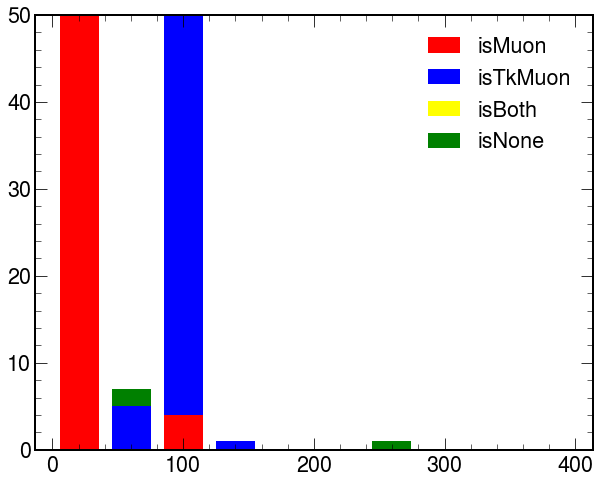

In [53]:
den_h, bins = np.histogram(denom, bins=10)
isNotMuon_h, _ = np.histogram(isNotMuon, bins=bins)
ismuon_h, _ = np.histogram(ismuon, bins=bins)
isTkmuon_h, _ = np.histogram(isTkmuon, bins=bins)
isboth_h, _ = np.histogram(isboth, bins=bins)
isNone_h, _ = np.histogram(isNone, bins=bins)
plt.figure(figsize=(10,8))
plt.style.use(hep.style.CMS)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
# plt.bar(bin_centers, ismuon_h/den_h,width=20, color="red")
# plt.bar(bin_centers, isTkmuon_h/den_h, bottom=ismuon_h/den_h,width=20, color="blue")
# plt.bar(bin_centers, isboth_h/den_h, bottom=ismuon_h/den_h+isTkmuon_h/den_h,width=20, color="yellow")
# plt.bar(bin_centers, isNone_h/den_h, bottom=ismuon_h/den_h+isTkmuon_h/den_h+isboth_h/den_h,width=20, color="green")
# plt.bar(bin_centers, isNotMuon_h/den_h, bottom=ismuon_h/den_h+isTkmuon_h/den_h+isboth_h/den_h+isNone_h/den_h, width=20, color="orange")
plt.bar(bin_centers, ismuon_h,width=30, color="red")
plt.bar(bin_centers, isTkmuon_h, bottom=ismuon_h,width=30, color="blue")
plt.bar(bin_centers, isboth_h, bottom=ismuon_h+isTkmuon_h,width=30, color="yellow")
plt.bar(bin_centers, isNone_h, bottom=ismuon_h+isTkmuon_h+isboth_h,width=30, color="green")
# plt.bar(bin_centers, isNotMuon_h, bottom=ismuon_h+isTkmuon_h+isboth_h+isNone_h, width=20, color="orange")
plt.legend(["isMuon", "isTkMuon", "isBoth", "isNone", "isNotMuon"])
plt.ylim(0,50)
plt.show()

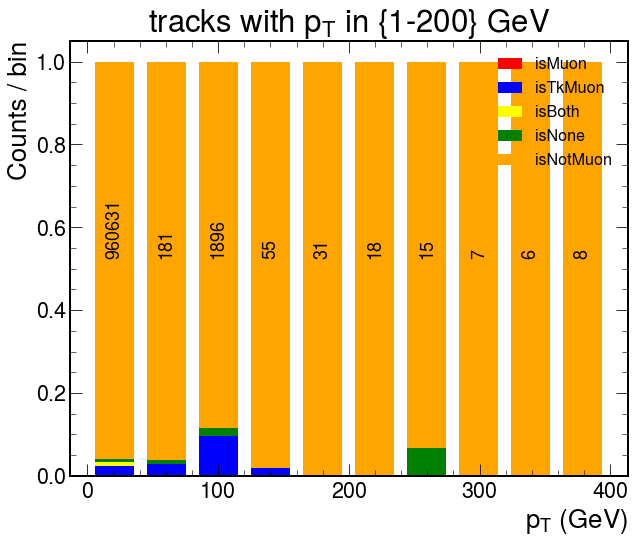

In [54]:
den_h, bins = np.histogram(denom, bins=10)
isNotMuon_h, _ = np.histogram(isNotMuon, bins=bins)
ismuon_h, _ = np.histogram(ismuon, bins=bins)
isTkmuon_h, _ = np.histogram(isTkmuon, bins=bins)
isboth_h, _ = np.histogram(isboth, bins=bins)
isNone_h, _ = np.histogram(isNone, bins=bins)
plt.figure(figsize=(10,8))
bin_centers = 0.5 * (bins[1:] + bins[:-1])
plt.bar(bin_centers, ismuon_h/den_h, width=30, color="red")
plt.bar(bin_centers, isTkmuon_h/den_h,  bottom=ismuon_h/den_h,width=30, color="blue")
plt.bar(bin_centers, isboth_h/den_h,    bottom=ismuon_h/den_h+isTkmuon_h/den_h,width=30, color="yellow")
plt.bar(bin_centers, isNone_h/den_h,    bottom=ismuon_h/den_h+isTkmuon_h/den_h+isboth_h/den_h,width=30, color="green")
ax = plt.bar(bin_centers, isNotMuon_h/den_h, bottom=ismuon_h/den_h+isTkmuon_h/den_h+isboth_h/den_h+isNone_h/den_h, width=30, color="orange")
for k, rect in enumerate(ax.patches):
    height = 0.5
    plt.text(rect.get_x()+rect.get_width()/2., 1.05*height, den_h[k],
                ha='center', va='bottom', fontsize=18, rotation="vertical")
plt.title(r"tracks with $p_T$ in {1-200} GeV")
plt.legend(["isMuon", "isTkMuon", "isBoth", "isNone", "isNotMuon"], fontsize=16)
plt.ylabel("Counts / bin")
plt.xlabel(r"$p_T$ (GeV)")
plt.show()

## candidates

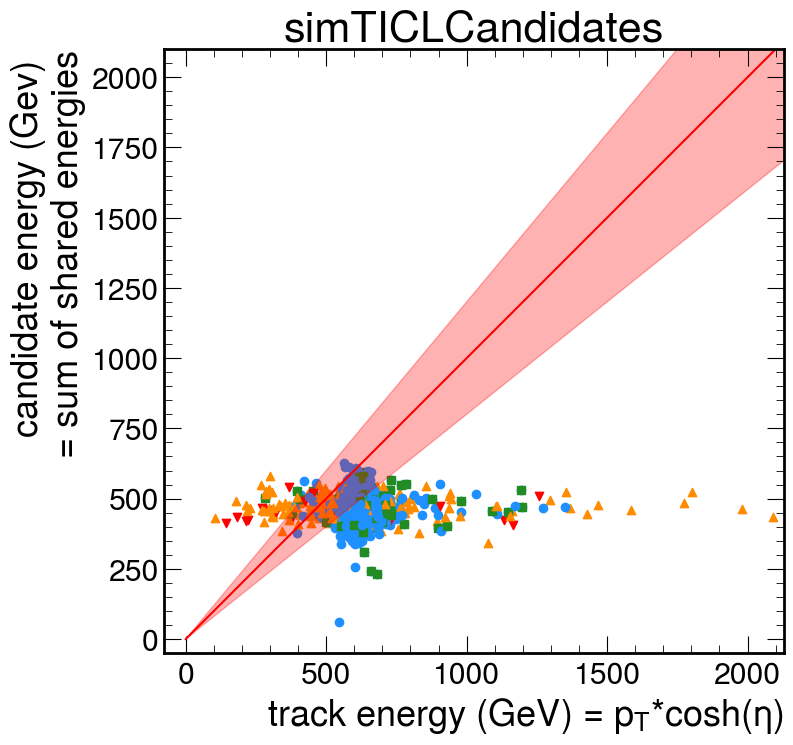

In [25]:
plt.figure(figsize=(8,8), dpi=100)
for tk_in_cand, cand_ene, cand_raw_ene, s2r_ene, trk_pt, trk_eta, trk_id, trk_miss, trk_nhits in zip(
        simTICLCandidate.simTICLCandidate_track_in_candidate, simTICLCandidate.simTICLCandidate_regressed_energy, 
        simTICLCandidate.simTICLCandidate_raw_energy, associations.ticlTracksterLinks_simToReco_CP_sharedE, track_pt, track_hgcal_eta, 
        track_id, track_missing_outer_hits, track_nhits):
    for i, tk in enumerate(tk_in_cand[tk_in_cand!=-1]):
        idx = find_track_id(trk_id, tk)
        if idx == -1: continue

        pt = trk_pt[idx]
        eta = trk_eta[idx]
        missing = trk_miss[idx]
#             print(s2r_ene[0], ak.sum(s2r_ene[0]))
        energy = ak.sum(s2r_ene[i]) #cand_ene[i] #cand_raw_ene[i] #
#             if pt*np.cosh(eta) > 3000:
#                 continue
        if not missing:
            plt.scatter(pt*np.cosh(eta), energy, c="dodgerblue")
#                 if pt*np.cosh(eta) / energy > 1.2 or pt*np.cosh(eta) / energy < 0.8:
#                     print(pt, eta, pt*np.cosh(eta) , cand_ene[i], energy, trk_nhits[idx] )
            if trk_nhits[idx] <= 15:
                plt.scatter(pt*np.cosh(eta), energy, c="forestgreen", marker="s")
        elif missing < 5:
            plt.scatter(pt*np.cosh(eta), energy, c="darkorange", marker = "^")
        else:
            plt.scatter(pt*np.cosh(eta), energy, c="red", marker = "v")
plt.xlabel("track energy (GeV) = $p_T$*cosh($\eta$)")
plt.ylabel("candidate energy (Gev) \n= sum of shared energies") # sum of LCs = raw  #CP energy") #
x = np.linspace(0,5000,100)
plt.plot(x, x, c="red")
plt.fill_between(x, x*0.8, x*1.2, color="red", alpha = 0.3)
plt.title("simTICLCandidates")
plt.axis("equal")
plt.xlim(-50,2100)
plt.ylim(-50,2100)
plt.show()

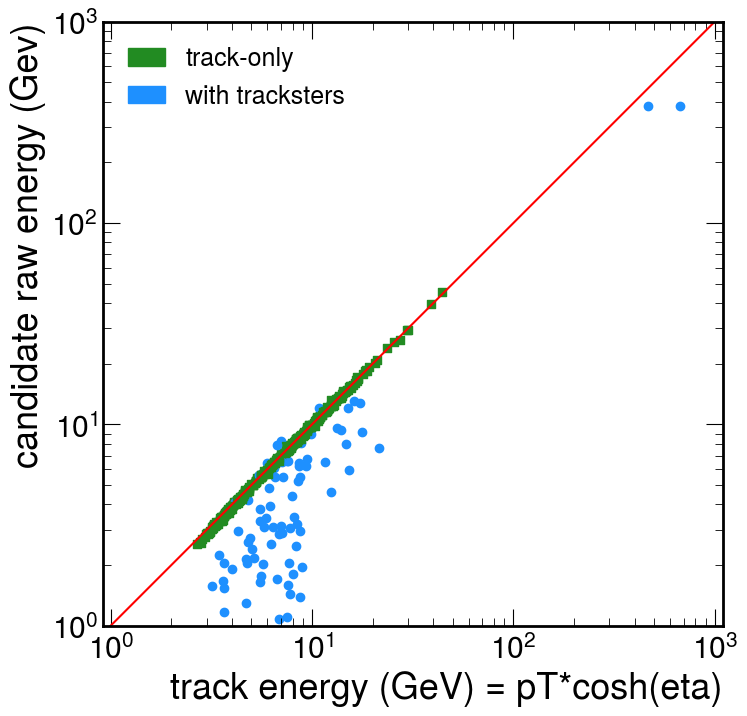

In [21]:
import matplotlib.patches as mpatches

plt.figure(figsize=(8,8), dpi=100)
empty = [0,0]
with_ts = [0,0]
for tk_in_cand, ts_in_cand, cand_ene, trk_pt, trk_eta, trk_id in zip(candidates.track_in_candidate, 
    candidates.tracksters_in_candidate, candidates.candidate_raw_energy, 
    track_hgcal_pt,track_hgcal_eta, track_id):
    for i, tk in enumerate(tk_in_cand[tk_in_cand!=-1]):
        idx = find_track_id(trk_id, tk)
        if idx == -1: continue
        pt = trk_pt[idx]
        eta = trk_eta[idx]
        if len(ts_in_cand[i])== 0:
            plt.scatter(pt*np.cosh(eta), cand_ene[i], c="forestgreen", marker="s")
        else:
            plt.scatter(pt*np.cosh(eta), cand_ene[i], c="dodgerblue")
    break
plt.xlabel("track energy (GeV) = pT*cosh(eta)")
plt.ylabel("candidate raw energy (Gev)")
x = np.linspace(0,1000,100)
plt.plot(x, x, c="red")
plt.axis("equal")
red_patch = mpatches.Patch(color='forestgreen', label='track-only')
blue_patch = mpatches.Patch(color='dodgerblue', label='with tracksters')
plt.legend(handles=[red_patch,blue_patch], loc= "upper left", fontsize=18)
plt.ylim(1,1000)
plt.xlim(1,1000)
plt.xscale("log")
plt.yscale("log")
plt.show()

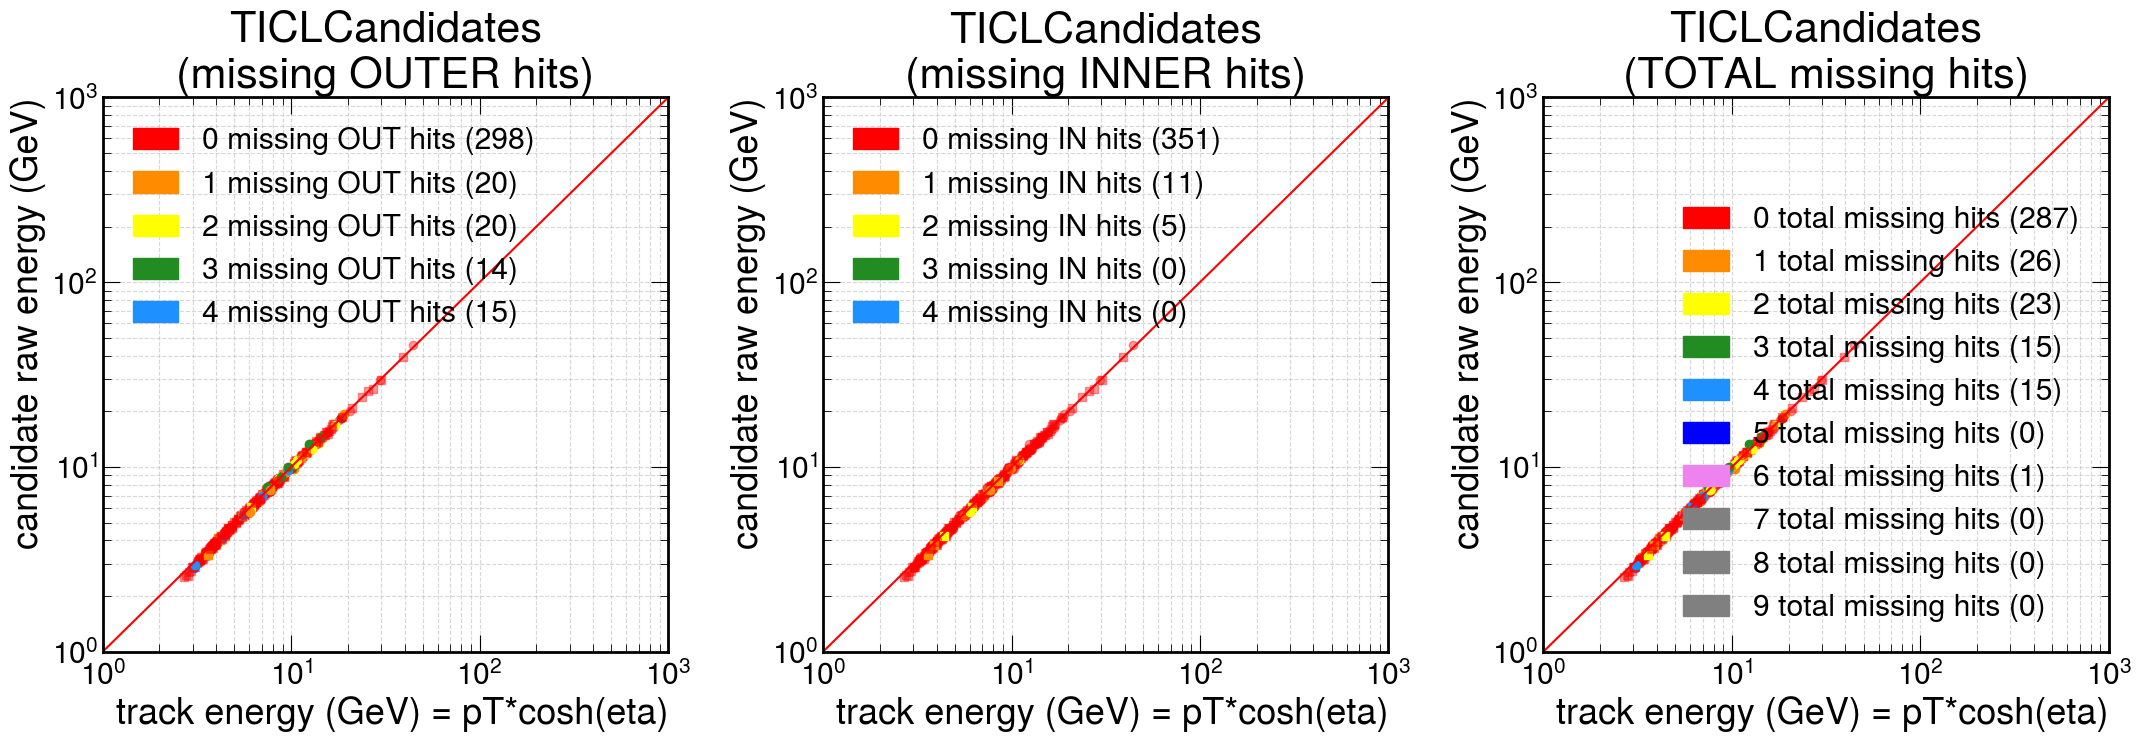

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

alphas = [0.4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
marker = ["o", "s", "s", "s"]
colors = ["red", "darkorange", "yellow", "forestgreen", "dodgerblue", "blue", "violet", "grey", "grey", "grey", "grey", "red", "darkorange", "yellow", "forestgreen", "dodgerblue", "blue", "violet", "grey", "grey", "grey", "grey"]

counts_missingOut = np.zeros(5)
counts_missingInn = np.zeros(5)
counts_missingTotal = np.zeros(10)  # Total can be larger than individual components

# Create three side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(22, 8), dpi=100)

for tk_in_cand, ts_in_cand, cand_ene, trk_pt, trk_eta, trk_id, trk_miss_out, trk_miss_in, trk_nhits in zip(
    candidates.track_in_candidate[candidates.track_in_candidate != -1],
    candidates.tracksters_in_candidate[candidates.track_in_candidate != -1],
    candidates.candidate_raw_energy[candidates.track_in_candidate != -1], 
    track_hgcal_pt, track_hgcal_eta, track_id, track_missing_outer_hits, track_missing_inner_hits, track_nhits
):
    for i, tk in enumerate(tk_in_cand):
        idx = find_track_id(trk_id, tk)
        if idx == -1 or len(ts_in_cand[i]) != 0:
            continue
        pt = trk_pt[idx]
        eta = trk_eta[idx]
        missingOut = trk_miss_out[idx]
        missingInn = trk_miss_in[idx]
        missingTotal = missingOut + missingInn
        nhits = trk_nhits[idx]

        # First plot: missingOut
        axes[0].scatter(pt * np.cosh(eta), cand_ene[i], c=colors[min(missingOut, len(colors) - 1)], alpha=alphas[min(missingOut, len(alphas) - 1)], marker=marker[nhits // 15])
        counts_missingOut[missingOut] += 1

        # Second plot: missingInn
        axes[1].scatter(pt * np.cosh(eta), cand_ene[i], c=colors[min(missingInn, len(colors) - 1)], alpha=alphas[min(missingInn, len(alphas) - 1)], marker=marker[nhits // 15])
        counts_missingInn[missingInn] += 1

        # Third plot: missingTotal
        axes[2].scatter(pt * np.cosh(eta), cand_ene[i], c=colors[min(missingTotal, len(colors) - 1)], alpha=alphas[min(missingTotal, len(alphas) - 1)], marker=marker[nhits // 15])
        counts_missingTotal[missingTotal] += 1
    break

# Plot diagonal reference line
x = np.linspace(0, 3000, 100)
for ax in axes:
    ax.plot(x, x, c="red")
    ax.set_xlabel("track energy (GeV) = pT*cosh(eta)")
    ax.set_ylabel("candidate raw energy (GeV)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1, 1000)
    ax.set_ylim(1, 1000)
    ax.set_axisbelow(True)
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

# Titles
axes[0].set_title("TICLCandidates\n(missing OUTER hits)")
axes[1].set_title("TICLCandidates\n(missing INNER hits)")
axes[2].set_title("TICLCandidates\n(TOTAL missing hits)")

# Legends
patches_missingOut = [mpatches.Patch(color=colors[i], label=f"{i} missing OUT hits ({int(counts_missingOut[i])})") for i in range(len(counts_missingOut))]
patches_missingInn = [mpatches.Patch(color=colors[i], label=f"{i} missing IN hits ({int(counts_missingInn[i])})") for i in range(len(counts_missingInn))]
patches_missingTotal = [mpatches.Patch(color=colors[i], label=f"{i} total missing hits ({int(counts_missingTotal[i])})") for i in range(len(counts_missingTotal))]

axes[0].legend(handles=patches_missingOut)
axes[1].legend(handles=patches_missingInn)
axes[2].legend(handles=patches_missingTotal)

plt.tight_layout()
plt.show()

In [140]:
def find_track_ids(array, numbers):
    # Create a dictionary mapping values to indices
    index_map = {val: idx for idx, val in enumerate(array)}
    # Use vectorized lookup, returning -1 if number is not found
    return np.array([index_map.get(num, -1) for num in numbers])

100%|██████████| 1000/1000 [00:19<00:00, 52.23it/s]


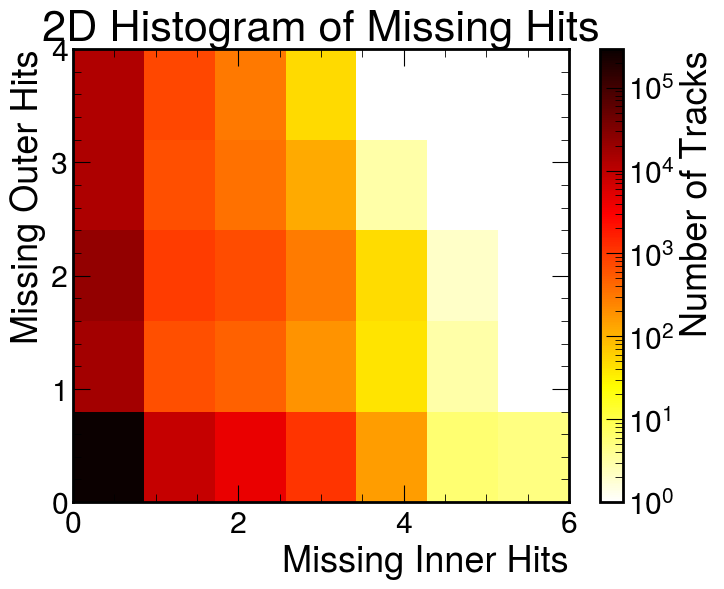

In [113]:
mask_valid_tracks = (candidates.track_in_candidate != -1)  # Exclude invalid candidates
mask_no_tracksters = (ak.num(candidates.tracksters_in_candidate, axis=2) == 0)  # Ensure no associated tracksters

mask = mask_valid_tracks & mask_no_tracksters

filtered_tracks_in_cand = candidates.track_in_candidate[mask]
filtered_tracksters_in_cand = candidates.tracksters_in_candidate[mask]
filtered_cand_ene = candidates.candidate_raw_energy[mask]

# Initialize lists to store valid missing hit values
missingOut_vals = []
missingInn_vals = []

for ev in tqdm(prange(len(filtered_tracks_in_cand))):
    tk_in_cand = filtered_tracks_in_cand[ev]
    ts_in_cand = filtered_tracksters_in_cand[ev]
    cand_ene = filtered_cand_ene[ev]
    trk_pt = track_hgcal_pt[ev]
    trk_eta = track_hgcal_eta[ev]
    trk_id = track_id[ev]
    trk_miss_out = track_missing_outer_hits[ev]
    trk_miss_in = track_missing_inner_hits[ev]
    
    ids = find_track_ids(trk_id, tk_in_cand)
    idx = ids[ids != -1]
    
    if len(idx)==0: continue

    missingOut = trk_miss_out[idx]
    missingInn = trk_miss_in[idx]

    # Store values for the histogram
    missingOut_vals.append(missingOut)
    missingInn_vals.append(missingInn)
        
# Convert to NumPy arrays
missingOut_vals = ak.to_numpy(ak.flatten(missingOut_vals))
missingInn_vals = ak.to_numpy(ak.flatten(missingInn_vals))

# Create 2D histogram
plt.figure(figsize=(8, 6), dpi=100)
hist, xedges, yedges, img = plt.hist2d(missingInn_vals, missingOut_vals, bins=((max(missingInn_vals)+1, max(missingOut_vals)+1)), cmap='hot_r', norm=mcolors.LogNorm())

# Add colorbar
cbar = plt.colorbar(img)
cbar.set_label("Number of Tracks")

# Labels and title
plt.xlabel("Missing Inner Hits")
plt.ylabel("Missing Outer Hits")
plt.title("2D Histogram of Missing Hits")

# Show plot
plt.show()

plot: selecting the non linked tracks plot the missing outer and inner hits for each track over the total number of hits, this against the linked tracks perhaps (put cut on pt as well)

1. loop over simTICLCandidates:
    - take the reco track 
    - take the associated reco trackster(s) -> quali? simtrackstersCP to lnked?
    - check if they were associated or not and why (time, energy, deltaR, no reco)
    - check also when trackster but no track
2. take the track collection and remove those that are in a candidate
    - why the others have not been associated? 
    - check cuts
    - check how to handle pu

In [157]:
@njit
def find_in_array_with_none(array, match):
    for i, el in enumerate(array):
        if len(el) == 0: continue
        if el[0] == match:
            return i
    return -1

In [164]:
# Initialize lists for different categories of track-trackster associations
all_energy = []
empty_but_reco_is_there = []
empty = []
reco_but_not_sim = [] 
wrong_energy = [] 
ok_energy = []
tracks_left = []
sh_ene_unlinked = []
sh_ene_wronglinked = []

ok = 0
den = 0
debug = False

SC_trackIdx = simtrackstersSC.trackIdx[simtrackstersSC.trackIdx!=-1]
SC_mapping = flat_indices[simtrackstersSC.trackIdx != -1]
SC_be = simtrackstersSC.raw_energy[simtrackstersSC.trackIdx!=-1]
s2r_SC_id = associations.ticlCandidate_simToReco_SC[simtrackstersSC.trackIdx!=-1]
s2r_SC_score = associations.ticlCandidate_simToReco_SC_score[simtrackstersSC.trackIdx!=-1]
s2r_SC_ene = associations.ticlCandidate_simToReco_SC_sharedE[simtrackstersSC.trackIdx!=-1]
mask = candidates.track_in_candidate != -1
filtered_tracks_in_cand = candidates.track_in_candidate[mask]
filtered_tracksters_in_cand = candidates.tracksters_in_candidate[mask]
filtered_cand_ene = candidates.candidate_raw_energy[mask]

for ev in tqdm(prange(len(SC_trackIdx))):
    SC_trackIdx_ev = SC_trackIdx[ev]
    SC_mapping_ev = SC_mapping[ev]
    SC_be_ev = SC_be[ev]
    trk_id = track_id[ev]
    trk_pt = track_hgcal_pt[ev]    
    trk_eta = track_hgcal_eta[ev]  
    trk_phi = track_hgcal_phi[ev]
    tracks_in_cand_ev = filtered_tracks_in_cand[ev]
    tracksters_in_cand_ev = filtered_tracksters_in_cand[ev]
    cand_ene_ev = filtered_cand_ene[ev]
    r2s_energy_ev = associations.ticlCandidate_recoToSim_SC_sharedE[ev]
    r2s_score_ev = associations.ticlCandidate_recoToSim_SC_score[ev]
    r2s_index_ev = associations.ticlCandidate_recoToSim_SC[ev]
    s2r_score_ev = s2r_SC_score[ev]
    s2r_ene_ev = s2r_SC_ene[ev]
    s2r_index_ev = s2r_SC_id[ev]
    canTs_eta = candTracksters.barycenter_eta[ev]
    canTs_phi = candTracksters.barycenter_phi[ev]
    canTs_ene = candTracksters.raw_energy[ev]
    tracks_left_ev =[]
    if debug: print(f"{ev=}, {SC_trackIdx_ev=}")
    for s, tid in enumerate(SC_trackIdx_ev):
        idx = find_track_id(trk_id, tid) # track position in the tracks arrays
        if idx == -1: 
            if debug: print("track in simtrackster but not in track collection (error?)")
            continue # track not found

        # Find the candidate associated with the track
        tid_in_cand = find_track_id(tracks_in_cand_ev, tid) # track position in the candidate arrays
        if tid_in_cand==-1: 
            if debug: print("track in simtrackster but not in candidate (error?)")
            tracks_left_ev.append(idx)
            continue # track is not in a candidate (should check why)

        # Store energy for efficiency calculation
        SC_be_ev_s = SC_be_ev[s]
        all_energy.append(SC_be_ev_s)  
        den += 1
        
        cand = tracksters_in_cand_ev[tid_in_cand]
        # if debug: print(tracksters_in_cand_ev, cand)

        # Case 1: Candidate exists but contains only a track (no tracksters)
        if len(cand) == 0:
#             score = s2r_score_ev[s]
#             match_found = np.any(score < 0.999) 
            match_found = np.any(s2r_ene_ev[s] / SC_be_ev_s > 0.2)
            
            if match_found:
                empty_but_reco_is_there.append(SC_be_ev_s)
                sh_ene_unlinked.append(max(s2r_ene_ev[s]) / SC_be_ev_s)
                if debug: print(f"{SC_be_ev_s}, empty_but_reco_is_there with energies {max(s2r_ene_ev[s]) / SC_be_ev_s}")
                tsMatched = s2r_index_ev[s][np.argmax(s2r_ene_ev[s])]
                tsMatched_in_cand = find_in_array_with_none(candidates.tracksters_in_candidate[ev], tsMatched)
#                 print(f"{trk_pt[idx]=}, {trk_eta[idx] - canTs_eta[tsMatched]}, {trk_phi[idx] - canTs_phi[tsMatched]}, {canTs_ene[tsMatched]}")
                print(f"{tsMatched=}, {tsMatched_in_cand}, {candidates.track_in_candidate[ev][tsMatched_in_cand]}") 
                # SONO QUI, CON QUESTO SO SE IL TRACKSTER HA CREATO UN NEUTRO O UN CARICO
            else:
                empty.append(SC_be_ev_s)
                if debug: print("empty")
            continue

        # Case 2: Tracksters exist → Find best-matching simTrackster
        ass = r2s_score_ev[cand][0]
        if len(ass)==0:
            reco_but_not_sim.append(SC_be_ev_s)
            if debug: print("reco_but_not_sim")
            continue
            
        s_in_ass = np.where(r2s_index_ev[cand][0] == SC_mapping_ev[s])[0]
        if len(s_in_ass)==0:
            reco_but_not_sim.append(SC_be_ev_s)
            if debug: print("reco_but_not_sim")
            continue
        else:
            s_in_ass = s_in_ass[0]
        
        s_argmin = np.argmin(ass)
        s_assoc = r2s_index_ev[cand][0][s_argmin]

        if SC_mapping_ev[s] == s_assoc or r2s_energy_ev[cand][0][s_in_ass]/cand_ene_ev[tid_in_cand] > 0.2:
            ok += 1 
            ok_energy.append(SC_be_ev_s)
            if debug: print("traccia ok")
        else:
            # check the CP !!
            sh_ene_wronglinked.append(r2s_energy_ev[cand][0][s_in_ass]/cand_ene_ev[tid_in_cand])
            print("linked:", s_in_ass, " min score:", s_argmin, " ene:", r2s_energy_ev[cand][0]/cand_ene_ev[tid_in_cand])
            wrong_energy.append(SC_be_ev_s)
            if debug: print("traccia sbagliata")
    tracks_left.append(tracks_left_ev)

  3%|▎         | 34/1000 [00:00<00:06, 158.83it/s]

tsMatched=84, 486, -1
tsMatched=71, 378, -1
tsMatched=721, 1194, -1
linked: 1  min score: 0  ene: [0.782, 0.0538, 0.0495, 0.0353, 0.00352, 0.00175]
tsMatched=320, 705, -1
tsMatched=109, 550, -1
tsMatched=84, 521, -1
tsMatched=78, 429, -1
tsMatched=60, 255, 1666


  7%|▋         | 66/1000 [00:00<00:06, 141.88it/s]

tsMatched=60, 372, -1
tsMatched=56, 226, 1675
tsMatched=615, 1014, -1
tsMatched=99, 527, -1
tsMatched=70, 445, -1
tsMatched=65, 367, -1
linked: 1  min score: 0  ene: [0.674, 0.057, 0.0571, 0.0248, 0.0379, ..., 0.00211, 0.0143, 0.000941, 0.00344]
tsMatched=103, 514, -1
tsMatched=103, 514, -1
tsMatched=275, 686, -1
linked: 1  min score: 0  ene: [0.37, 0.14, 0.0775, 0.0407, 0.0725, 0.0483, 0.0148]
tsMatched=41, 184, 1308
tsMatched=72, 455, -1
tsMatched=65, 429, -1
tsMatched=81, 488, -1


 12%|█▏        | 120/1000 [00:00<00:05, 157.09it/s]

...

tsMatched=138, 548, -1
tsMatched=138, 548, -1
tsMatched=92, 537, -1
tsMatched=67, 397, -1
tsMatched=76, 505, -1
tsMatched=75, 474, -1
tsMatched=70, 309, -1
tsMatched=59, 497, -1
tsMatched=98, 488, -1
tsMatched=32, 110, 1263
tsMatched=59, 382, -1
tsMatched=974, 1466, -1
linked: 9  min score: 0  ene: [0.255, 0.193, 0.0655, 0.0303, 0.0323, ..., 0.0205, 0.0156, 0.0103, 0.00362]
tsMatched=242, 655, -1


 94%|█████████▍| 944/1000 [00:05<00:00, 165.95it/s]

tsMatched=41, 263, -1
tsMatched=71, 375, -1
tsMatched=67, 369, -1
tsMatched=67, 369, -1
tsMatched=67, 369, -1
tsMatched=75, 380, -1
tsMatched=92, 456, -1
tsMatched=73, 491, -1
tsMatched=73, 359, -1


100%|██████████| 1000/1000 [00:06<00:00, 161.49it/s]

tsMatched=80, 455, -1
tsMatched=61, 392, -1
tsMatched=72, 442, -1
tsMatched=73, 418, -1
tsMatched=81, 430, -1
tsMatched=59, 382, -1


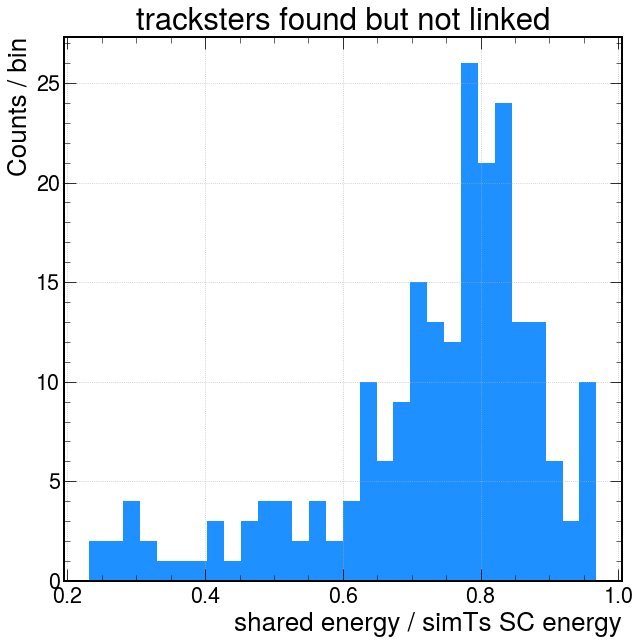

In [86]:
myhist(sh_ene_unlinked, xlabel="shared energy / simTs SC energy", title="tracksters found but not linked")

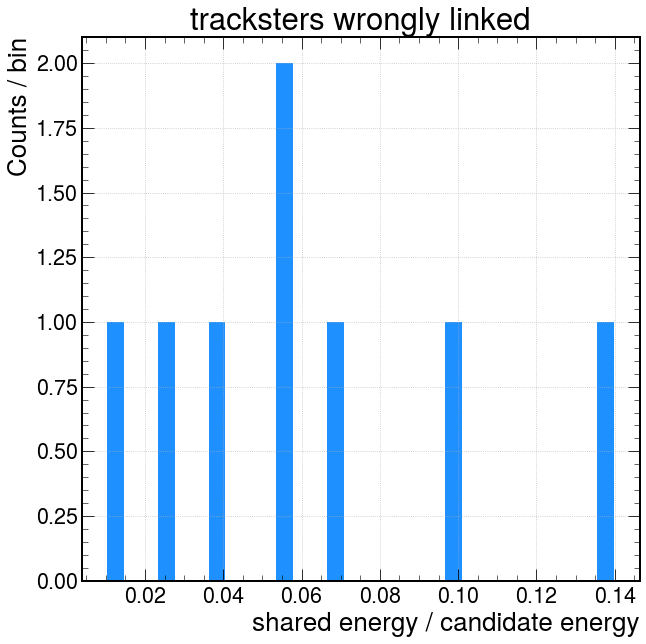

In [87]:
myhist(sh_ene_wronglinked, xlabel="shared energy / candidate energy", title="tracksters wrongly linked")

In [88]:
# Initialize counters for unlinked track reasons
total_unlinked_counts = {
    "total": 0,
    "low_pt": 0,
    "high_missing_hits": 0,
    "bad_quality": 0
}

# Iterate over events
for ev in tqdm(prange(len(track_id))):
    # Analyze unassociated tracks
    unassociated_tracks = tracks_left[ev]
    # Count why tracks were not linked
    total_unlinked_counts["total"] += len(unassociated_tracks)
    total_unlinked_counts["low_pt"] += np.sum(track_pt[ev][unassociated_tracks] < 1)
    total_unlinked_counts["high_missing_hits"] += np.sum(track_missing_outer_hits[ev][unassociated_tracks] > 5)
    total_unlinked_counts["bad_quality"] += np.sum(track_quality[ev][unassociated_tracks]==0)

# Print final counts
print("Total number of unlinked tracks by reason:")
for reason, count in total_unlinked_counts.items():
    print(f"{reason}: {count}")

# Print summary
print(f"Total Tracks Processed: {den}")
print(f"Correctly Associated Tracks: {ok}")
print(f"Tracks with No Reco Trackster: {len(empty)}")
print(f"Tracks with Reco Match but No Candidate: {len(empty_but_reco_is_there)}")
print(f"Tracks with wrong track associated: {len(wrong_energy)}")
# print(f"Unassociated Tracks Breakdown: {unlinked_reasons}")

100%|██████████| 1000/1000 [00:02<00:00, 408.52it/s]

Total number of unlinked tracks by reason:
total: 54
low_pt: 44
high_missing_hits: 2
bad_quality: 4
Total Tracks Processed: 1813
Correctly Associated Tracks: 1557
Tracks with No Reco Trackster: 25
Tracks with Reco Match but No Candidate: 221
Tracks with wrong track associated: 8


In [89]:
def error_division(num, den):
    error = np.zeros_like(num, dtype=float)
    valid_mask = (num != 0) & (den != 0)
    error[valid_mask] = (num[valid_mask] / den[valid_mask]) * np.sqrt((1 / num[valid_mask])**2 + (1 / den[valid_mask])**2)
    return error

/tmp/ipykernel_450/4081369577.py:9: RuntimeWarning: invalid value encountered in divide
  ax1.errorbar(bins[:-1], hist_1/hist_0, error_division(hist_1, hist_0), marker='o', markersize=7, linestyle='none', capsize=5)
/tmp/ipykernel_450/4081369577.py:11: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(bins[:-1], hist_2/hist_0, error_division(hist_2, hist_0), marker='o', markersize=7, linestyle='none', capsize=5)
/tmp/ipykernel_450/4081369577.py:13: RuntimeWarning: invalid value encountered in divide
  ax3.errorbar(bins[:-1], hist_3/hist_0, error_division(hist_3, hist_0), marker='o', markersize=7, linestyle='none', capsize=5)
/tmp/ipykernel_450/4081369577.py:15: RuntimeWarning: invalid value encountered in divide
  ax4.errorbar(bins[:-1], hist_4/hist_0, error_division(hist_4, hist_0), marker='o', markersize=7, linestyle='none', capsize=5)


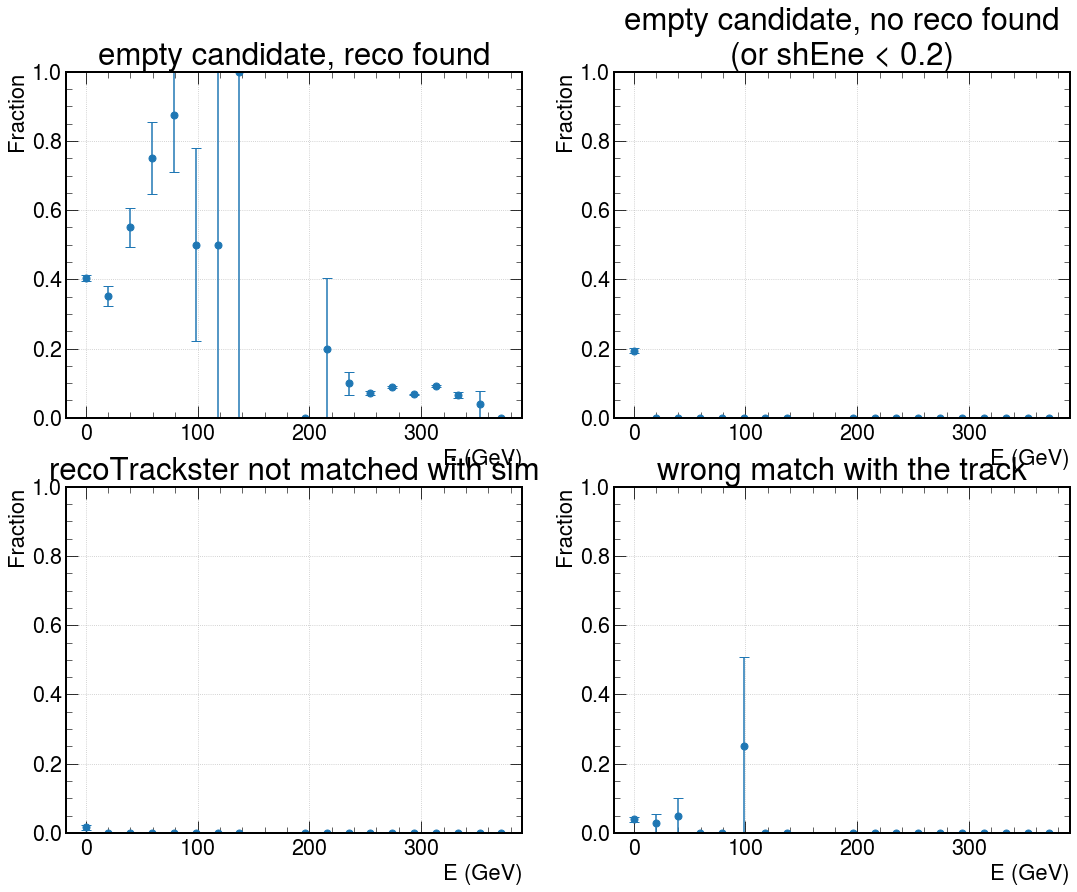

In [90]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(18,14))

hist_0, bins = np.histogram(ok_energy+empty_but_reco_is_there+empty+reco_but_not_sim+wrong_energy, bins=20)
hist_1, _    = np.histogram(empty_but_reco_is_there, bins=bins)
hist_2, _    = np.histogram(empty, bins=bins)
hist_3, _    = np.histogram(reco_but_not_sim, bins=bins)
hist_4, _    = np.histogram(wrong_energy, bins=bins)

ax1.errorbar(bins[:-1], hist_1/hist_0, error_division(hist_1, hist_0), marker='o', markersize=7, linestyle='none', capsize=5)
ax1.set_title("empty candidate, reco found")
ax2.errorbar(bins[:-1], hist_2/hist_0, error_division(hist_2, hist_0), marker='o', markersize=7, linestyle='none', capsize=5)
ax2.set_title("empty candidate, no reco found\n(or shEne < 0.2)")
ax3.errorbar(bins[:-1], hist_3/hist_0, error_division(hist_3, hist_0), marker='o', markersize=7, linestyle='none', capsize=5)
ax3.set_title("recoTrackster not matched with sim")
ax4.errorbar(bins[:-1], hist_4/hist_0, error_division(hist_4, hist_0), marker='o', markersize=7, linestyle='none', capsize=5)
ax4.set_title("wrong match with the track")

ax1.set_xlabel('E (GeV)', size=22)
ax1.set_ylabel('Fraction', size=22)
ax1.set_ylim(0,1)
ax1.grid()

ax2.set_xlabel('E (GeV)', size=22)
ax2.set_ylabel('Fraction', size=22)
ax2.set_ylim(0,1)
ax2.grid()

ax3.set_xlabel('E (GeV)', size=22)
ax3.set_ylabel('Fraction', size=22)
ax3.set_ylim(0,1)
ax3.grid()

ax4.set_xlabel('E (GeV)', size=22)
ax4.set_ylabel('Fraction', size=22)
ax4.set_ylim(0,1)
ax4.grid()

plt.show()

In [91]:
# save inidices of non linked candidates